# Reddit Data EDA

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
SUBREDDITS = ['Futurology', 'artificial', 'singularity', 'MachineLearning']
COLORS     = dict(zip(SUBREDDITS, sns.color_palette('tab10', 4)))
FIG_DIR    = 'figures/'

import os
if FIG_DIR:
    os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    if FIG_DIR:
        # plt.savefig(f'{FIG_DIR}{name}_raw.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{FIG_DIR}{name}_clean.png', dpi=150, bbox_inches='tight')


## 1. Load & Basic Overview

In [40]:
# df = pd.read_csv('reddit_ai_posts_RAW.csv')
df = pd.read_csv('reddit_ai_posts_CLEAN.csv')

# Parse datetime
df['created_dt'] = pd.to_datetime(df['created_utc'], unit='s', errors='coerce')

def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    text = re.sub(r'[*_~`>#]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

DELETED = {'[deleted]', '[removed]', ''} # list of common deleted/removed indicators

df['title_clean']    = df['title'].apply(clean_text)
df['selftext_clean'] = df['selftext'].apply(clean_text)
df['has_body']       = df['selftext'].apply(lambda x: isinstance(x, str) and x.strip() not in DELETED)
df['body_word_count']  = df['selftext_clean'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df['title_word_count'] = df['title_clean'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df['text'] = df.apply(
    lambda r: (r['title_clean'] + ' ' + r['selftext_clean']).strip() if r['has_body'] else r['title_clean'],
    axis=1
)
df['text_word_count'] = df['text'].apply(lambda x: len(x.split()))

print(f'Shape: {df.shape}')
print(f'Date range: {df.created_dt.min().date()} to {df.created_dt.max().date()}')
print()
print(df.groupby('subreddit').size().rename('post_count'))

Shape: (1395, 20)
Date range: 2023-01-02 to 2026-05-11

subreddit
Futurology         250
MachineLearning    451
artificial         403
singularity        291
Name: post_count, dtype: int64


## 2. Subreddit Compositions

                 total  pct_self  pct_has_body  pct_no_body
subreddit                                                  
Futurology         250     100.0         100.0          0.0
MachineLearning    451     100.0         100.0          0.0
artificial         403     100.0         100.0          0.0
singularity        291     100.0         100.0          0.0


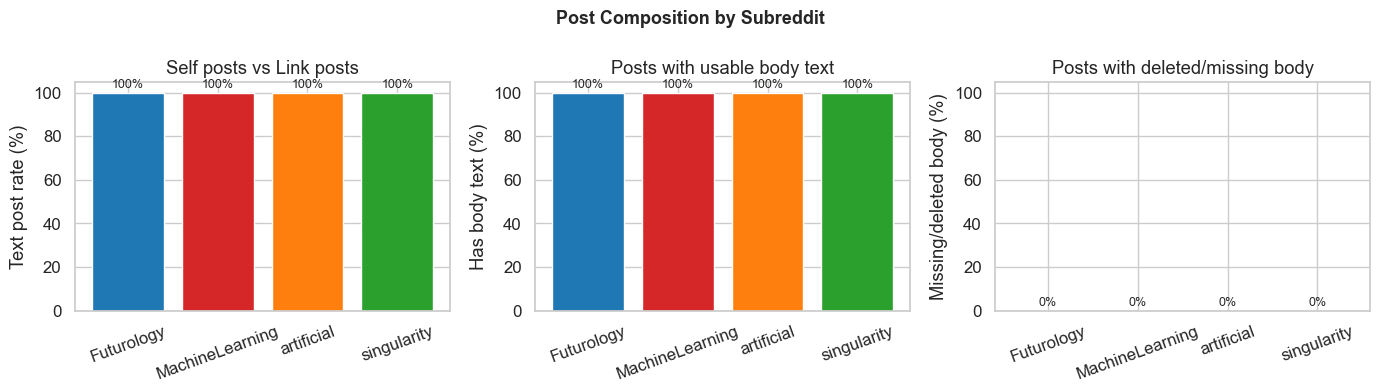

In [41]:
# Per-subreddit: % self posts, % with body, % deleted body
comp = df.groupby('subreddit').agg(
    total        = ('id', 'count'),
    pct_self     = ('is_self', lambda x: x.fillna(False).mean() * 100),
    pct_has_body = ('has_body', lambda x: x.mean() * 100),
).round(1)
comp['pct_no_body'] = (100 - comp['pct_has_body']).round(1)
print(comp)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ('pct_self',     'Text post rate (%)',    'Self posts vs Link posts'),
    ('pct_has_body', 'Has body text (%)',      'Posts with usable body text'),
    ('pct_no_body',  'Missing/deleted body (%)', 'Posts with deleted/missing body'),
]
for ax, (col, ylabel, title) in zip(axes, metrics):
    bars = ax.bar(comp.index, comp[col], color=[COLORS[s] for s in comp.index])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, comp[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Post Composition by Subreddit', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('01_post_composition')
plt.show()

## 3. Word Count Distributions
Use these plots to decide on `MIN_WORD_COUNT` threshold.

/var/folders/0q/5xqmqp2d5xj8gz_gfkw5v3380000gn/T/ipykernel_10601/4103702990.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(sub_data, patch_artist=True, labels=[f'r/{s}' for s in SUBREDDITS])


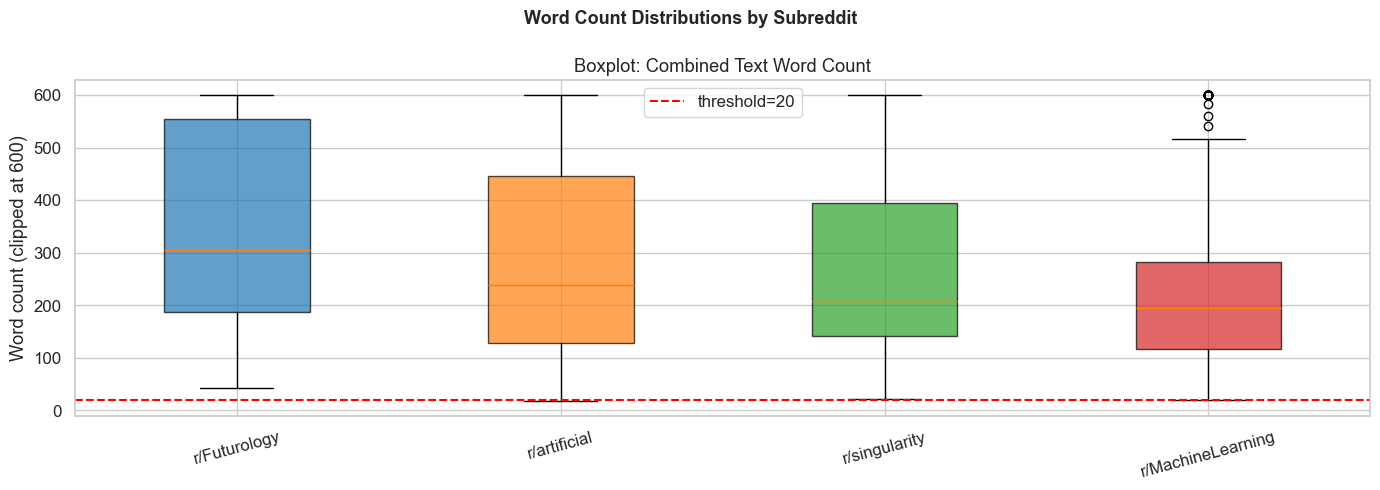

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# --- Right: Box plot of combined word count ---
sub_data = [df[df['subreddit'] == s]['text_word_count'].clip(upper=600) for s in SUBREDDITS]
bp = ax.boxplot(sub_data, patch_artist=True, labels=[f'r/{s}' for s in SUBREDDITS])
for patch, sub in zip(bp['boxes'], SUBREDDITS):
    patch.set_facecolor(COLORS[sub])
    patch.set_alpha(0.7)
ax.axhline(20, color='red', linestyle='--', linewidth=1.5, label='threshold=20')
ax.set_ylabel('Word count (clipped at 600)')
ax.set_title('Boxplot: Combined Text Word Count')
ax.tick_params(axis='x', rotation=15)
ax.legend()

plt.suptitle('Word Count Distributions by Subreddit', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('02_word_count_distributions')
plt.show()

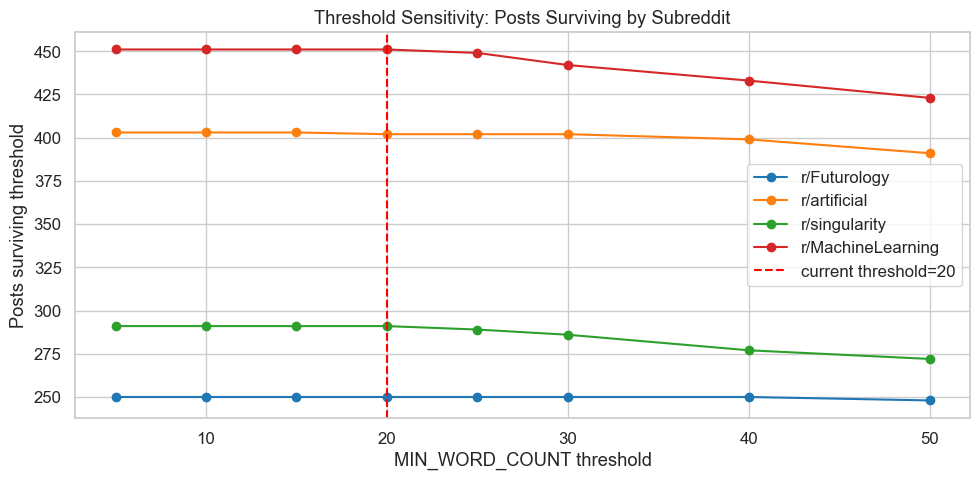

Posts surviving at MIN_WORD_COUNT = 20:
  r/Futurology          : 250/250 (100.0%)
  r/artificial          : 402/403 (99.8%)
  r/singularity         : 291/291 (100.0%)
  r/MachineLearning     : 451/451 (100.0%)


In [43]:
# Threshold sensitivity: how many posts survive at different MIN_WORD_COUNT values?
thresholds = [5, 10, 15, 20, 25, 30, 40, 50]

fig, ax = plt.subplots(figsize=(10, 5))
for sub in SUBREDDITS:
    sub_df = df[df['subreddit'] == sub]
    counts = [( sub_df['text_word_count'] >= t).sum() for t in thresholds]
    ax.plot(thresholds, counts, marker='o', label=f'r/{sub}', color=COLORS[sub])

ax.axvline(20, color='red', linestyle='--', linewidth=1.5, label='current threshold=20')
ax.set_xlabel('MIN_WORD_COUNT threshold')
ax.set_ylabel('Posts surviving threshold')
ax.set_title('Threshold Sensitivity: Posts Surviving by Subreddit')
ax.legend()
plt.tight_layout()
savefig('03_threshold_sensitivity')
plt.show()

#  threshold=20 picked
print('Posts surviving at MIN_WORD_COUNT = 20:')
for sub in SUBREDDITS:
    n = (df[df['subreddit'] == sub]['text_word_count'] >= 20).sum()
    total = (df['subreddit'] == sub).sum()
    print(f'  r/{sub:<20}: {n}/{total} ({100*n/total:.1f}%)')

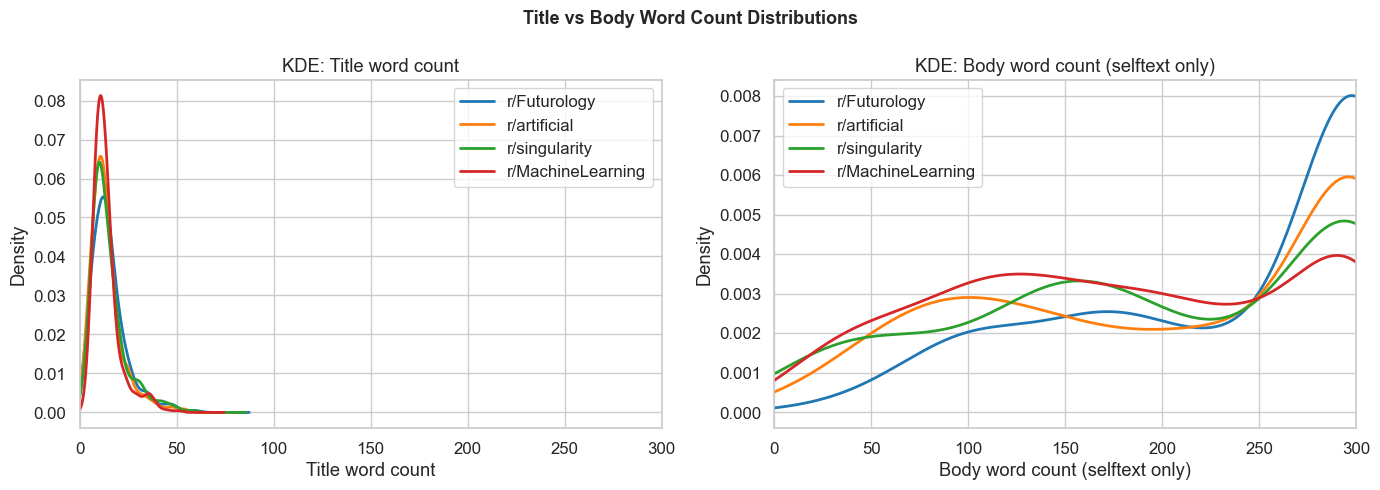

In [44]:
# Title-only vs title+body word count comparison by density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes,
    ['title_word_count', 'body_word_count'],
    ['Title word count', 'Body word count (selftext only)']):
    for sub in SUBREDDITS:
        data = df[df['subreddit'] == sub][col].clip(upper=300)
        data.plot.kde(ax=ax, label=f'r/{sub}', color=COLORS[sub], linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'KDE: {label}')
    ax.set_xlim(0, 300)
    ax.legend()

plt.suptitle('Title vs Body Word Count Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('04_title_vs_body_wordcount')
plt.show()

## 6. Class Balance Check

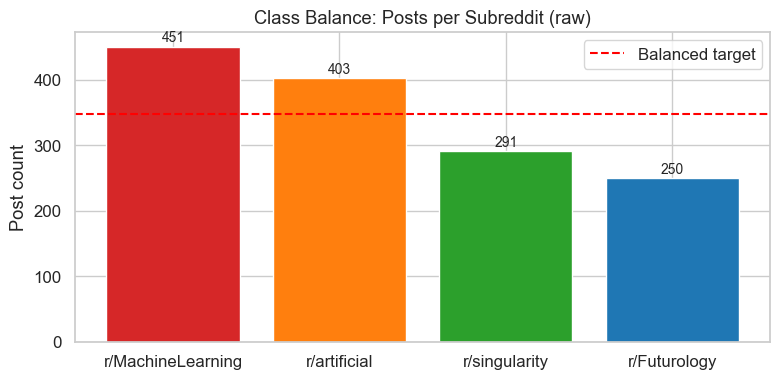

Imbalance ratio (max/min): 1.8


In [45]:
counts = df.groupby('subreddit').size().sort_values(ascending=False)
total  = counts.sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'r/{s}' for s in counts.index], counts.values,
              color=[COLORS[s] for s in counts.index])
ax.axhline(total / 4, color='red', linestyle='--', linewidth=1.5, label='Balanced target')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Post count')
ax.set_title('Class Balance: Posts per Subreddit (raw)')
ax.legend()
plt.tight_layout()
savefig('08_class_balance')
plt.show()

print('Imbalance ratio (max/min):', round(counts.max() / counts.min(), 2))